1.获取数据（我们选可口可乐KO和百事可乐PEP，他们是天生一对）
注意，需要用节点才能访问yahoo finance（创建session）

[*********************100%***********************]  2 of 2 completed


正在通过手机台湾节点批量下载 ['KO', 'PEP'] 的历史数据...
🎉 数据下载成功！正在生成走势对比图...


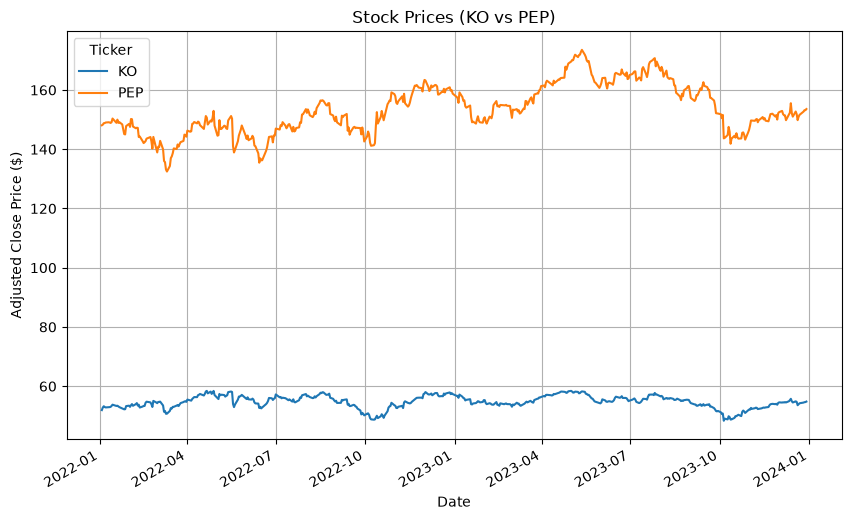

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'zh-TW,zh;q=0.9,en-US;q=0.8,en;q=0.7'
})
# 2. 配置你的手机局域网代理
PHONE_IP = "192.168.1.136"  
MIXED_PORT = "7890"         

proxy_url = f"http://{PHONE_IP}:{MIXED_PORT}"
session.proxies.update({
    'http': proxy_url,
    'https': proxy_url
})

# 3. 定义你想下载的股票代码（可口可乐和百事可乐）
tickers = ["KO", "PEP"]

print(f"正在通过手机节点批量下载 {tickers} 的历史数据...")

# 4. 核心：在 yf.download 中传入配置好的 session
# 这样它就会完全走你的手机代理，绝不会报 rate limit 错误
data = yf.download(tickers, start='2022-01-01', end='2024-01-01', session=session,auto_adjust=False)['Adj Close']

# 5. 检查数据并直接画图
if not data.empty:
    print("🎉 数据下载成功！正在生成走势对比图...")
    
else:
    print("❌ 下载的数据为空，请检查代理网络连接。")


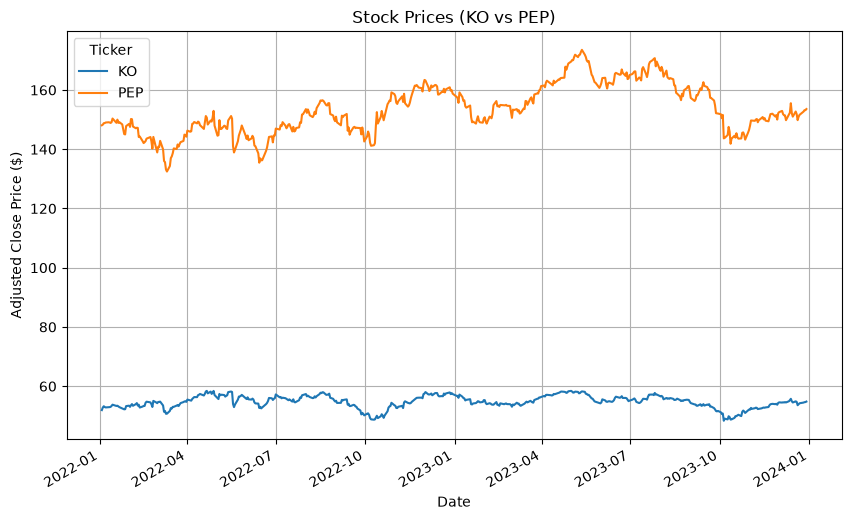

In [24]:
data.plot(figsize=(10, 6), title="Stock Prices (KO vs PEP)")
plt.ylabel("Adjusted Close Price ($)")
plt.grid(True)
plt.show() # 如果在 VS Code 里运行，记得加这行才能弹出图表窗口

<Axes: title={'center': 'Stock Prices'}>

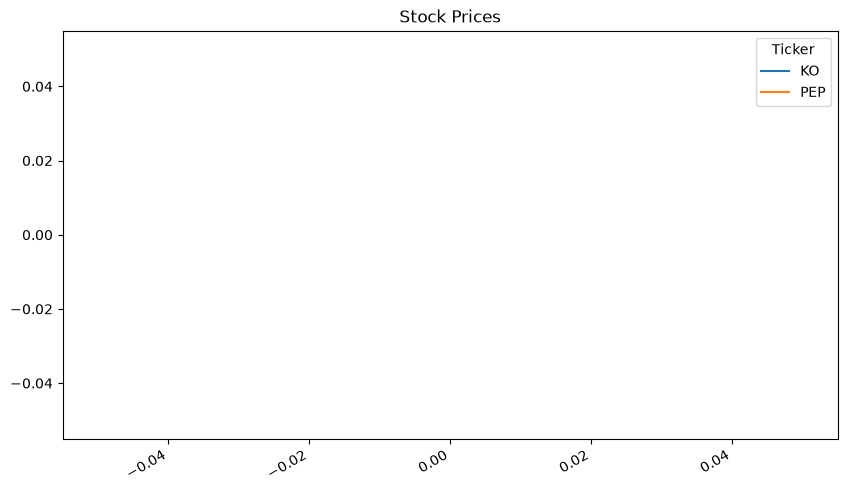

2.计算价差（spread）和Z-Score(标准化得分)
逻辑：两只股平时形影不离，如果有一天价差拉的太开（Z-Score>2），他们迟早会回归

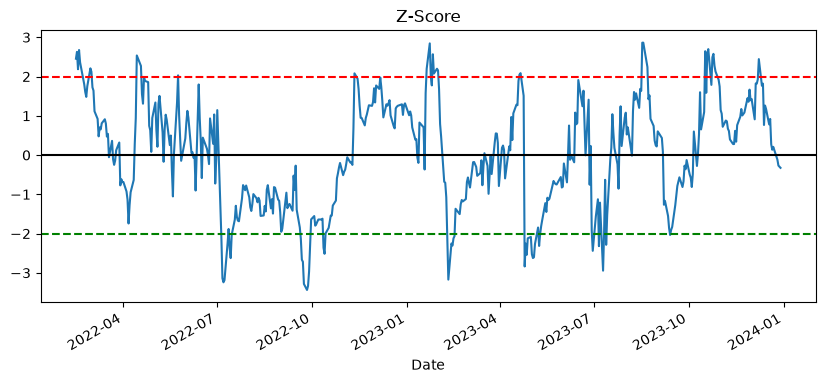

In [25]:
# 计算比值（ratio）
data['ratio']=data['KO']/data['PEP']
# 计算比值的滚动均值和标准差（取30天窗口）
data['mean']=data['ratio'].rolling(window=30).mean()
data['std']=data['ratio'].rolling(window=30).std()
# 计算Z-Score:当前比值偏离均值多少个标准差
data['z_score']=(data['ratio']-data['mean'])/data['std']

data['z_score'].plot(figsize=(10,4),title='Z-Score')
plt.axhline(2,color='r',linestyle='--') #上轨：卖出信号
plt.axhline(-2,color='g',linestyle='--') #下轨：买入信号
plt.axhline(0,color='black') # 均值

3.产生交易信号并计算收益
cumprod()累积连乘，计算累计复利收益

<Axes: title={'center': 'Strategy Performance'}, xlabel='Date'>

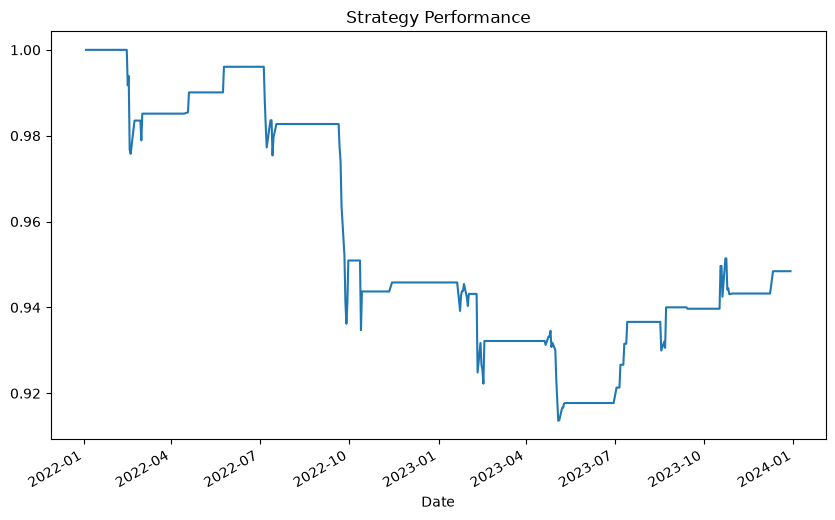

In [26]:
# 定义策略：Z>2卖出，Z<-2买入
data['signal']=0
data.loc[data['z_score']>2,'signal']=-1 #卖出
data.loc[data['z_score']<-2,'signal']=1 #买入

# 计算收益（简单模拟）
data['returns']=data['ratio'].pct_change()
data['strategy_returns']=data['signal'].shift(1)*data['returns']

# 计算累计收益并画图
data['cumulative_returns']=(1+data['strategy_returns'].fillna(0)).cumprod()
data['cumulative_returns'].plot(figsize=(10,6),title="Strategy Performance")